In [ ]:
!pip install pmdarima
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from statsmodels.graphics.tsaplots import plot_acf , plot_pacf
from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.stattools import adfuller
from math import sqrt
from sklearn.metrics import r2_score , mean_absolute_error , mean_absolute_percentage_error , mean_squared_error
import pickle
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 3.0 MB/s eta 0:00:00


In [ ]:
df = pd.read_csv("/content/Foreign_Exchange_Rates.xls")
df.head()

,Unnamed: 0,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,...,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$,Unnamed: 24
0,0,03-01-2000,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,...,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97,NaN
1,1,04-01-2000,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,...,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13,NaN
2,2,05-01-2000,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,...,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1,NaN
3,3,06-01-2000,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,...,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62,NaN
4,4,07-01-2000,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,...,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3,NaN


##Pre processing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Data columns (total 25 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Unnamed: 0                                 5217 non-null   int64  
 1   Time Serie                                 5217 non-null   object 
 2   AUSTRALIA - AUSTRALIAN DOLLAR/US$          5217 non-null   object 
 3   EURO AREA - EURO/US$                       5217 non-null   object 
 4   NEW ZEALAND - NEW ZELAND DOLLAR/US$        5217 non-null   object 
 5   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5217 non-null   object 
 6   BRAZIL - REAL/US$                          5217 non-null   object 
 7   CANADA - CANADIAN DOLLAR/US$               5217 non-null   object 
 8   CHINA - YUAN/US$                           5217 non-null   object 
 9   HONG KONG - HONG KONG DOLLAR/US$           5217 non-null   object 
 10  INDIA - INDIAN RUPEE/US$

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns = df.columns.str.strip()
df['Time Serie'] = pd.to_datetime(df['Time Serie'], format = '%d-%m-%Y')

In [ ]:
df = df.set_index('Time Serie')
df = df.sort_index()

In [ ]:
df = df.replace('ND', pd.NA) #removing non numeric values
df = df.apply(pd.to_numeric)

In [ ]:
# Drop the 'Unnamed: 0' and 'Unnamed: 24' columns as they are not relevant
df = df.drop(columns=['Unnamed: 0', 'Unnamed: 24'], errors='ignore')
display(df.head())

,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,KOREA - WON/US$,...,SINGAPORE - SINGAPORE DOLLAR/US$,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$
Time Serie,,,,,,,,,,,,,,,,,,,,,
2000-01-03,1.5172,0.9847,1.9033,0.6146,1.8050,1.4465,8.2798,7.7765,43.55,1128.0,...,1.6563,7.3290,101.70,3.8,7.964,8.4430,72.30,1.5808,31.38,36.97
2000-01-04,1.5239,0.9700,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,43.55,1122.5,...,1.6535,7.2180,103.09,3.8,7.934,8.3600,72.65,1.5565,30.60,37.13
2000-01-05,1.5267,0.9676,1.9339,0.6092,1.8560,1.4518,8.2798,7.7780,43.55,1135.0,...,1.6560,7.2080,103.77,3.8,7.935,8.3530,72.95,1.5526,30.80,37.10
2000-01-06,1.5291,0.9686,1.9436,0.6070,1.8400,1.4571,8.2797,7.7785,43.55,1146.5,...,1.6655,7.2125,105.19,3.8,7.940,8.3675,72.95,1.5540,31.75,37.62
2000-01-07,1.5272,0.9714,1.9380,0.6104,1.8310,1.4505,8.2794,7.7783,43.55,1138.0,...,1.6625,7.2285,105.17,3.8,7.966,8.4150,73.15,1.5623,30.85,37.30


In [ ]:
df = df.asfreq('D')
df = df.fillna(method = 'ffill') #forward fill

In [ ]:
#df = df.diff().iloc[1:]

In [ ]:
df.isnull().sum()

,0
AUSTRALIA - AUSTRALIAN DOLLAR/US$,0
EURO AREA - EURO/US$,0
NEW ZEALAND - NEW ZELAND DOLLAR/US$,0
UNITED KINGDOM - UNITED KINGDOM POUND/US$,0
BRAZIL - REAL/US$,0
CANADA - CANADIAN DOLLAR/US$,0
CHINA - YUAN/US$,0
HONG KONG - HONG KONG DOLLAR/US$,0
INDIA - INDIAN RUPEE/US$,0
KOREA - WON/US$,0


##EDA

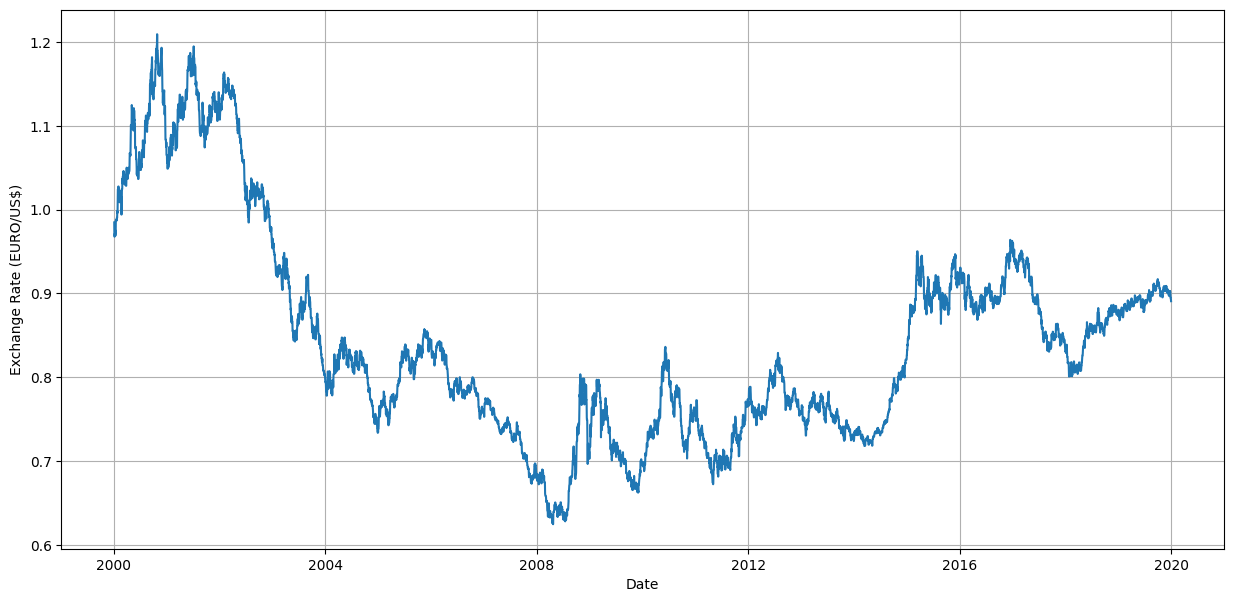

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(df.index, df['EURO AREA - EURO/US$'])
plt.xlabel('Date')
plt.ylabel('Exchange Rate (EURO/US$)')
plt.grid(True)
plt.show()

In [ ]:
df_week = df.resample('W').mean()
print('Count of The Weekly Data Frame : ',df_week.shape[0])

Count of The Weekly Data Frame :  1044


In [ ]:
df_week.head()

,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,KOREA - WON/US$,...,SINGAPORE - SINGAPORE DOLLAR/US$,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$
Time Serie,,,,,,,,,,,,,,,,,,,,,
2000-01-09,1.525500,0.972157,1.931229,0.610414,1.833500,1.451243,8.279629,7.777914,43.550000,1135.142857,...,1.659829,7.236143,104.180000,3.8,7.953000,8.395500,72.900000,1.561543,31.011429,37.245714
2000-01-16,1.508843,0.978971,1.923471,0.609429,1.815071,1.452486,8.279629,7.778743,43.564286,1133.642857,...,1.670771,7.285286,105.828571,3.8,7.986214,8.443286,73.342857,1.578729,30.821429,37.508571
2000-01-23,1.506414,0.988743,1.945557,0.607529,1.787243,1.446714,8.279514,7.779257,43.592857,1128.000000,...,1.677643,7.361286,105.295714,3.8,7.997286,8.482286,73.178571,1.595514,30.852857,37.331429
2000-01-30,1.558471,1.010900,2.008171,0.611957,1.782714,1.442900,8.278329,7.780071,43.634286,1123.900000,...,1.698171,7.521071,106.228571,3.8,8.155286,8.664357,73.200000,1.629271,30.804286,37.494286
2000-02-06,1.576986,1.023071,2.028329,0.624114,1.782286,1.446257,8.278129,7.780914,43.645714,1128.928571,...,1.695714,7.613857,107.705714,3.8,8.253000,8.693857,73.500000,1.645743,30.928571,37.564286


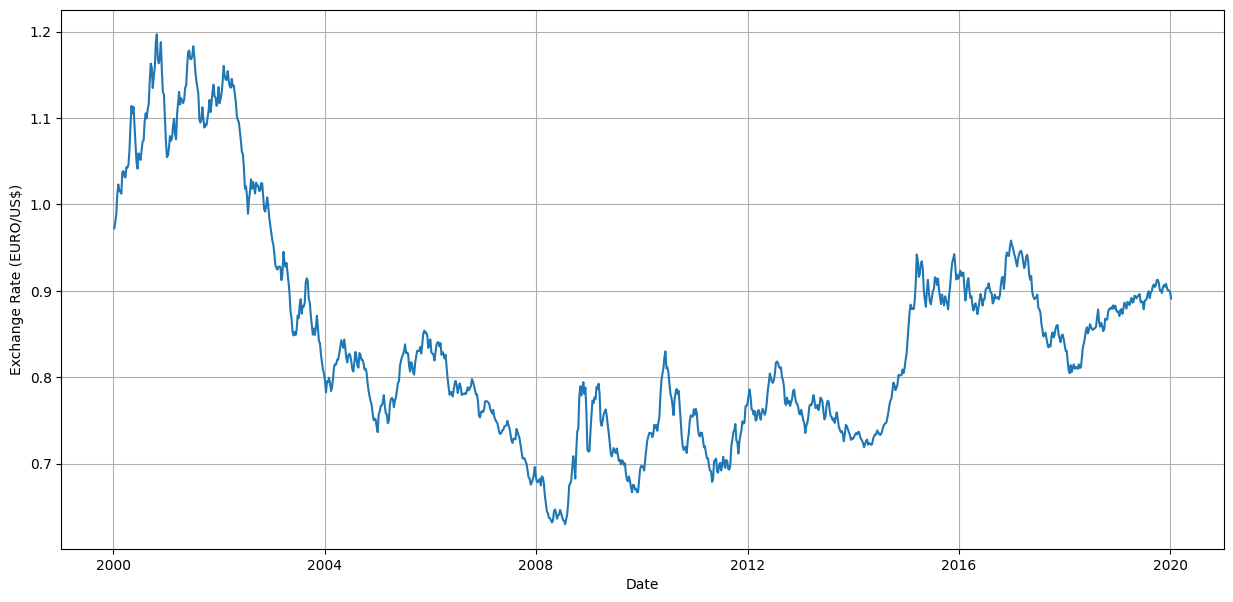

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(df_week.index, df_week['EURO AREA - EURO/US$'])
plt.xlabel('Date')
plt.ylabel('Exchange Rate (EURO/US$)')
plt.grid(True)
plt.show()

In [ ]:
df_month = df.resample('M').mean()
print('Count of The Monthly Data Frame : ',df_month.shape[0])

Count of The Monthly Data Frame :  240


In [ ]:
df_month.head()

,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,KOREA - WON/US$,...,SINGAPORE - SINGAPORE DOLLAR/US$,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$
Time Serie,,,,,,,,,,,,,,,,,,,,,
2000-01-31,1.526259,0.988976,1.954414,0.610114,1.804541,1.448452,8.279221,7.779066,43.587586,1129.958621,...,1.677445,7.360672,105.450345,3.8,8.032534,8.507345,73.167241,1.593272,30.868276,37.400345
2000-02-29,1.593841,1.017755,2.038862,0.625759,1.775483,1.450869,8.278152,7.781586,43.655862,1129.169310,...,1.702434,7.578803,109.497586,3.8,8.245086,8.652017,73.548966,1.635517,30.788621,37.766207
2000-03-31,1.641535,1.036171,2.041745,0.632890,1.741055,1.460981,8.278597,7.784661,43.641290,1116.463871,...,1.715313,7.716455,106.448710,3.8,8.403900,8.696468,73.822581,1.662206,30.723710,37.913548
2000-04-30,1.678017,1.059040,2.018300,0.632427,1.770283,1.468897,8.279257,7.788007,43.687800,1109.726667,...,1.709160,7.889807,105.554000,3.8,8.624560,8.747743,74.121000,1.666640,30.525833,37.980833
2000-05-31,1.728939,1.102671,2.127190,0.663681,1.829177,1.496216,8.278016,7.790810,44.082903,1120.490323,...,1.728597,8.222523,108.158387,3.8,9.046435,9.089348,74.894194,1.716729,30.773226,38.950323


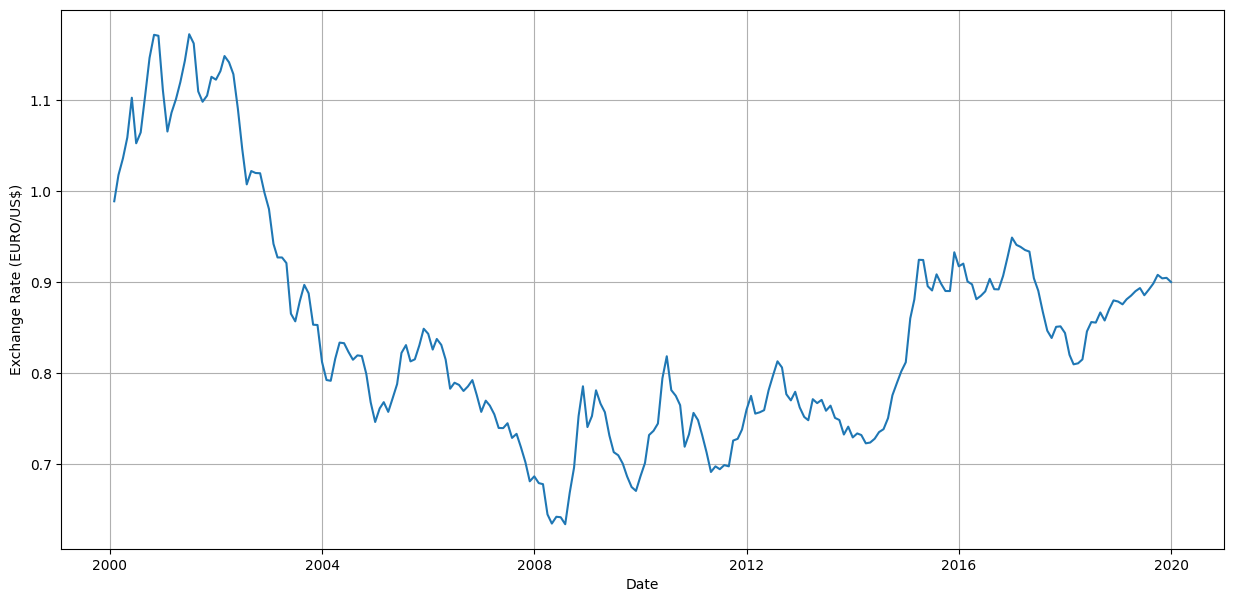

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(df_month.index, df_month['EURO AREA - EURO/US$'])
plt.xlabel('Date')
plt.ylabel('Exchange Rate (EURO/US$)')
plt.grid(True)
plt.show()

In [ ]:
df_year = df.resample('Y').mean()
print('Count of The Yearly Data Frame : ',df_year.shape[0])

Count of The Yearly Data Frame :  20


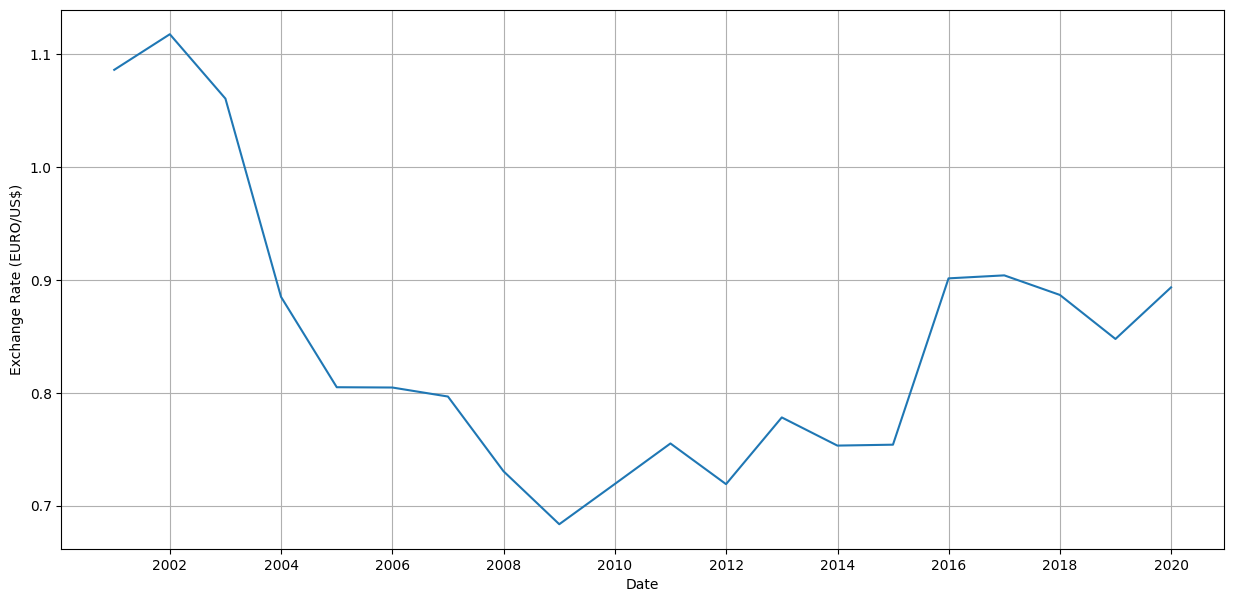

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(df_year.index, df_year['EURO AREA - EURO/US$'])
plt.xlabel('Date')
plt.ylabel('Exchange Rate (EURO/US$)')
plt.grid(True)
plt.show()

In [ ]:
df_year.head()

,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,KOREA - WON/US$,...,SINGAPORE - SINGAPORE DOLLAR/US$,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$
Time Serie,,,,,,,,,,,,,,,,,,,,,
2000-12-31,1.727738,1.086215,2.205385,0.661357,1.831127,1.485711,8.278413,7.792439,45.010973,1131.476044,...,1.724940,8.094646,107.858571,3.800001,8.811888,9.176332,77.002335,1.689985,31.265761,40.225588
2001-12-31,1.935242,1.117769,2.380559,0.694569,2.354867,1.549056,8.277010,7.799657,47.233644,1291.723479,...,1.792612,8.330309,121.547753,3.800007,8.992878,10.340097,89.615411,1.688304,33.834515,44.521595
2002-12-31,1.840787,1.060702,2.160091,0.666402,2.923758,1.570219,8.277010,7.799596,48.620247,1249.990986,...,1.790344,7.882737,125.171699,3.800018,7.979523,9.717737,95.768795,1.556075,34.538110,43.025272
2003-12-31,1.540615,0.885033,1.722194,0.612150,3.075128,1.400592,8.277162,7.787287,46.588466,1191.841370,...,1.742721,6.576951,115.919836,3.800000,7.075938,8.077499,96.534767,1.344922,34.402605,41.549753
2004-12-31,1.359905,0.804928,1.508484,0.546076,2.925743,1.301035,8.276792,7.788737,45.274508,1145.952186,...,1.690177,5.989030,108.137486,3.800000,6.740037,7.347459,101.236516,1.242755,33.381672,40.269891


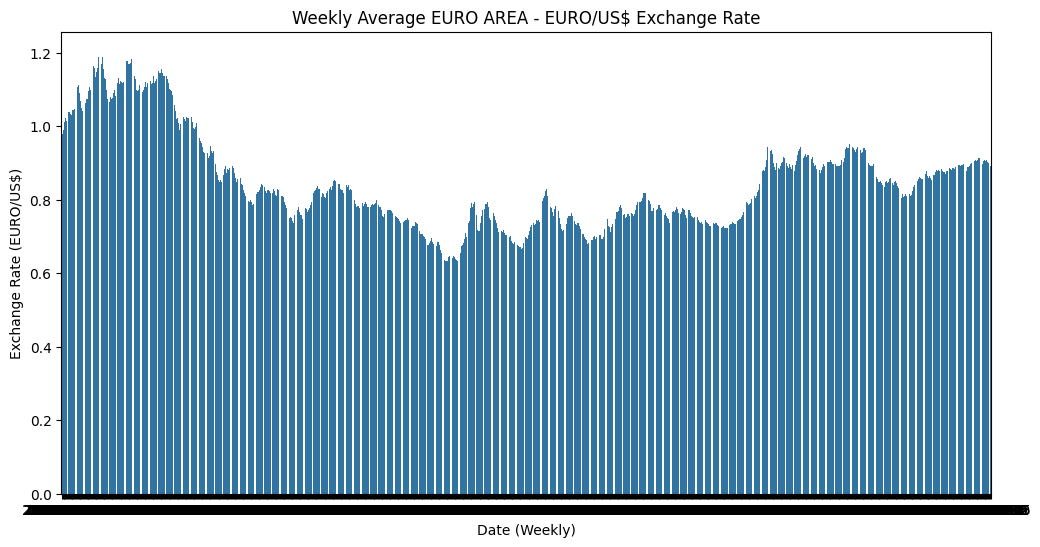

In [ ]:
sns.barplot(x=df_week.index, y=df_week['EURO AREA - EURO/US$'])
plt.xlabel('Date (Weekly)')
plt.ylabel('Exchange Rate (EURO/US$)')
plt.title('Weekly Average EURO AREA - EURO/US$ Exchange Rate')
plt.show()

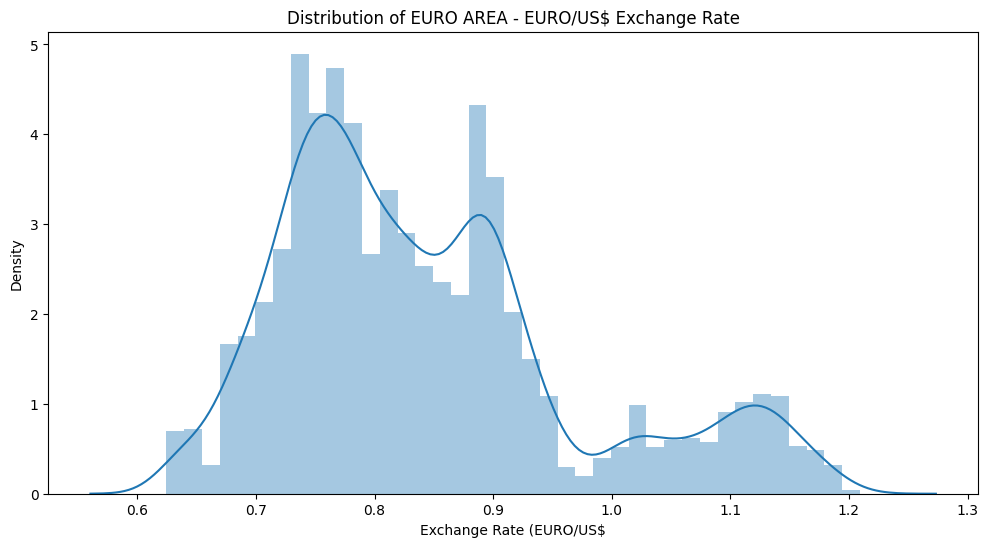

In [ ]:
sns.distplot(df['EURO AREA - EURO/US$'])
plt.xlabel('Exchange Rate (EURO/US$')
plt.title('Distribution of EURO AREA - EURO/US$ Exchange Rate')
plt.show()

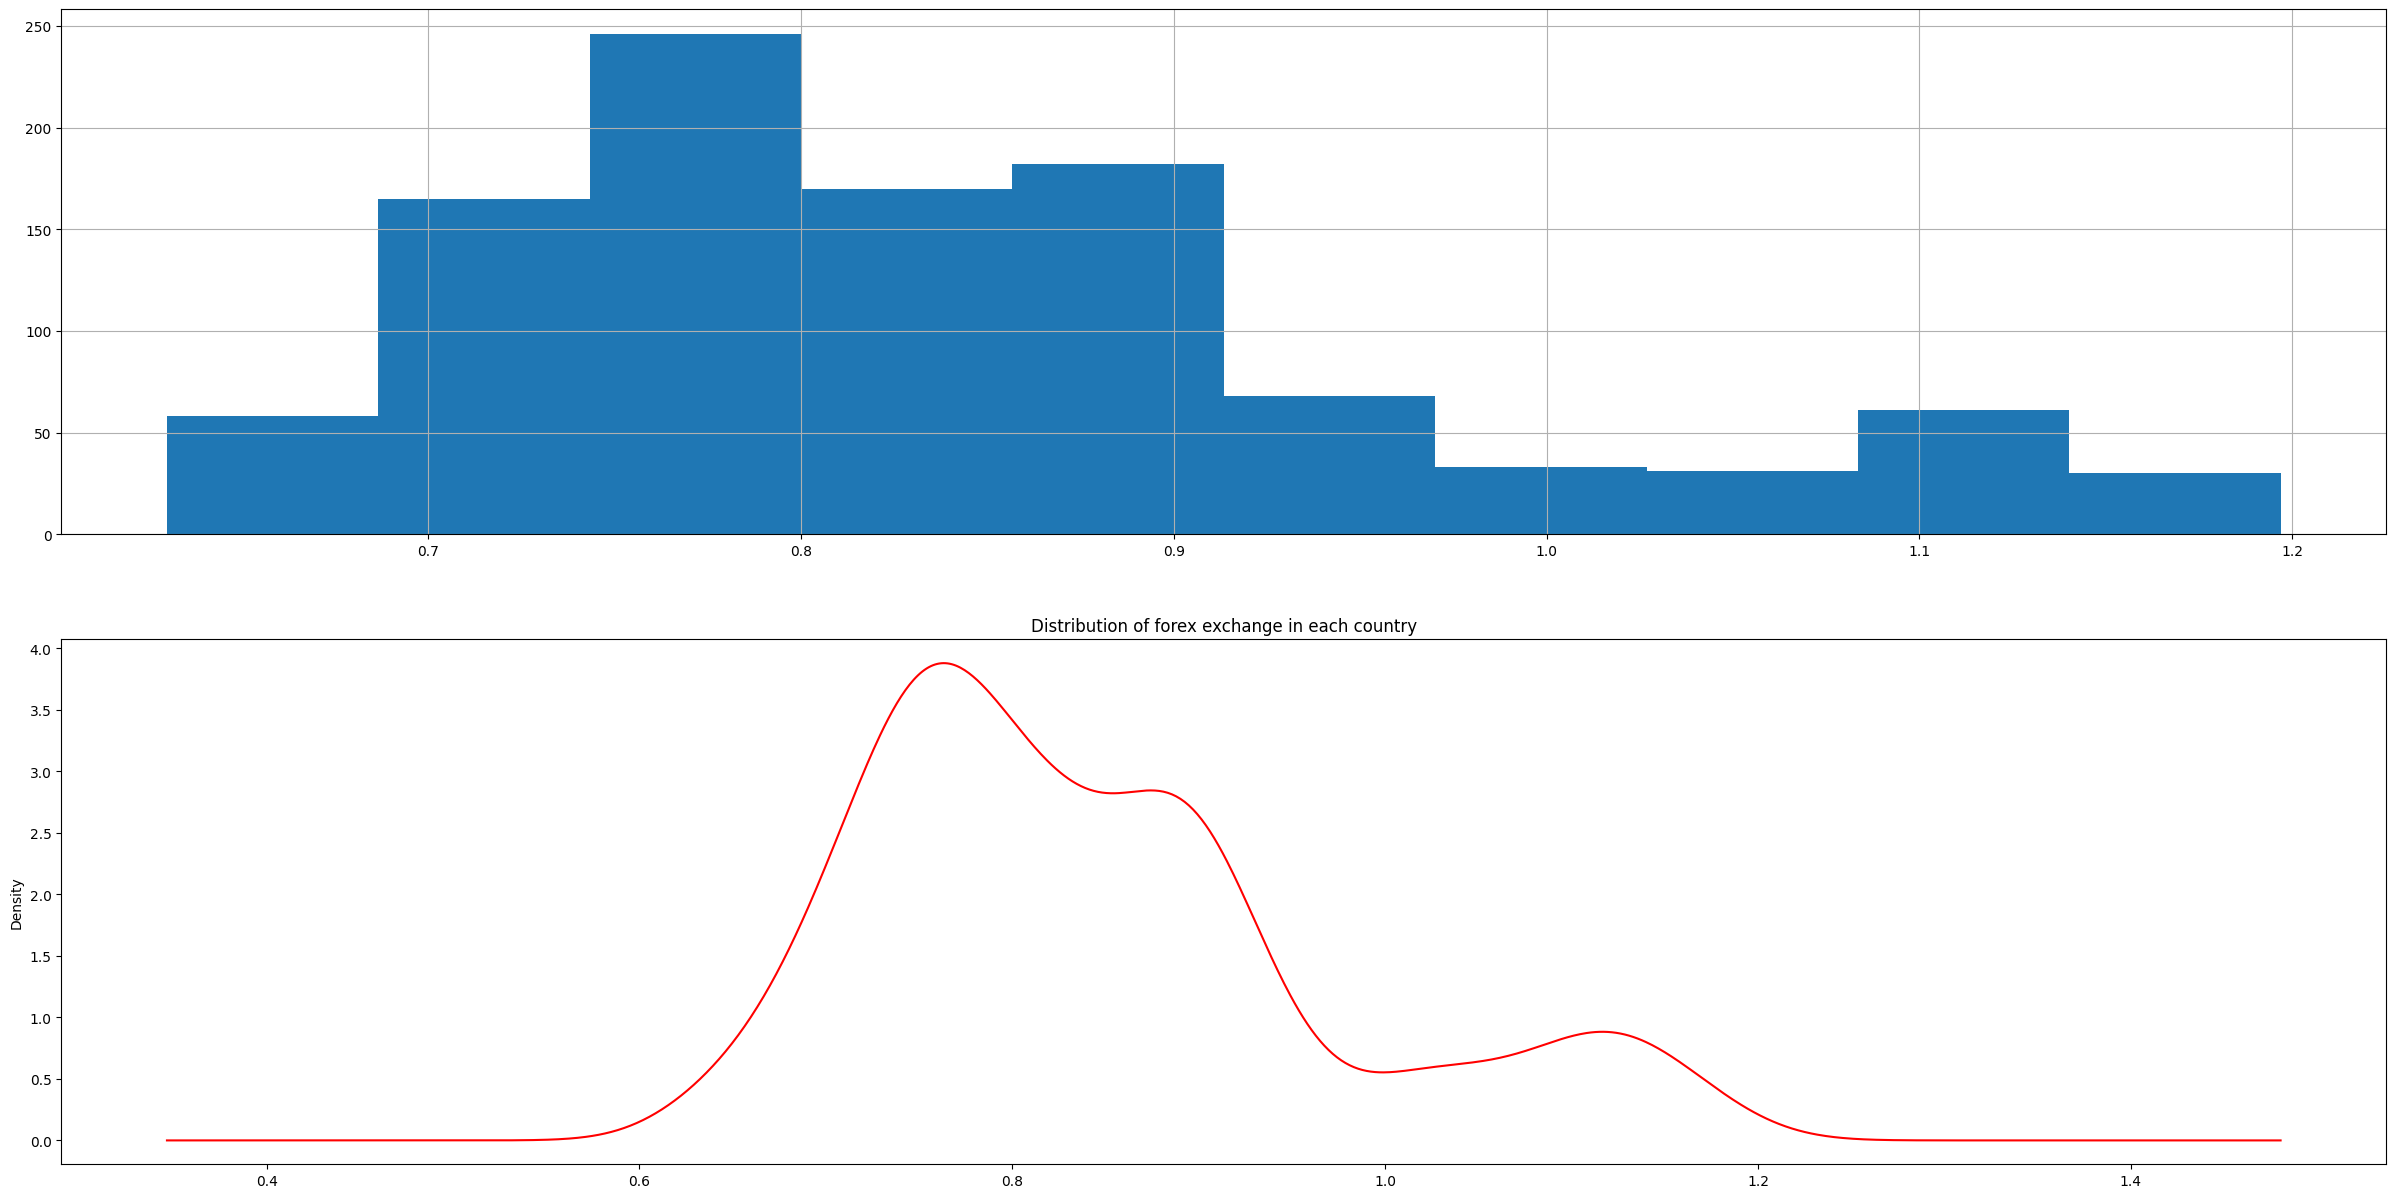

In [ ]:
fig, (ax1,ax2) = plt.subplots(nrows = 2, ncols = 1, sharex = False , sharey = False, figsize =(30,15))
df_week['EURO AREA - EURO/US$'].hist(ax =ax1)
df_week['EURO AREA - EURO/US$'].plot(kind = 'kde', ax =ax2, c ='r')
plt.title('Distribution of forex exchange in each country')
plt.show()

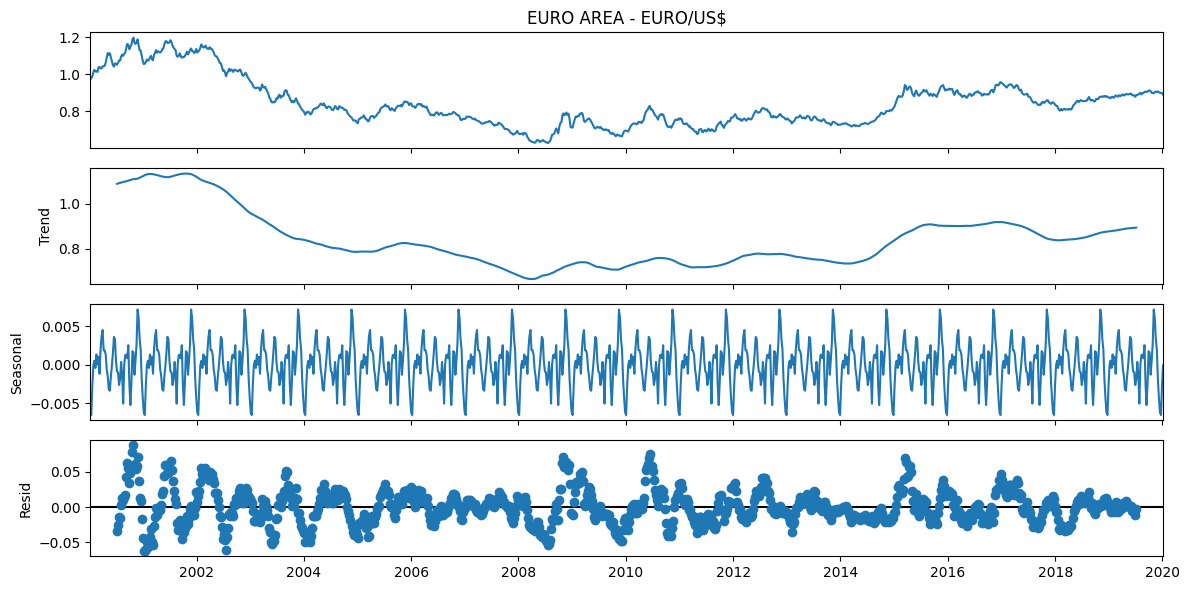

In [ ]:
plt.rcParams['figure.figsize']=(12,6)
decomposition = seasonal_decompose(df_week['EURO AREA - EURO/US$'], period = 52 , model = 'additive')
decomposition.plot()
#plt.savefig('Discription , trend , seasonal , residuals.png')
plt.show()

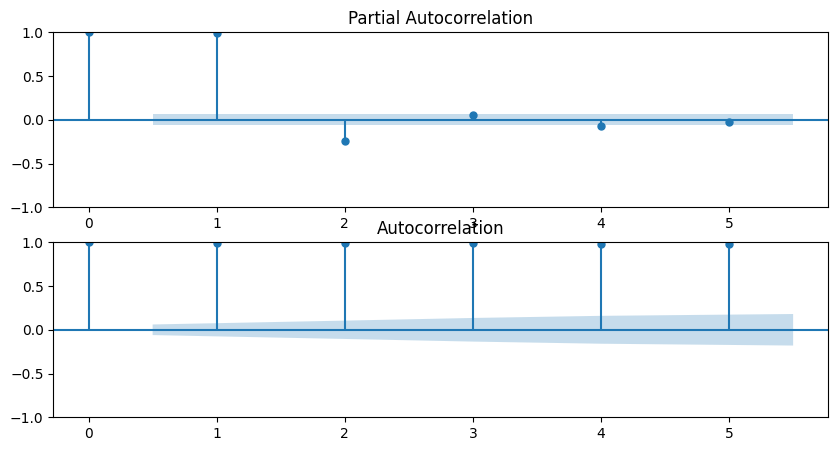

In [ ]:
fig , (ax1,ax2) = plt.subplots(nrows = 2 ,ncols = 1,sharex = False , sharey = False , figsize = (10,5))
ax1 = plot_pacf(df_week['EURO AREA - EURO/US$'] , lags = 5 , ax = ax1)
ax2 = plot_acf(df_week['EURO AREA - EURO/US$'] , lags = 5 , ax = ax2)
plt.show()

In [ ]:
def adf_check(time_series):
    result = adfuller(time_series , autolag = 'AIC')
    label = pd.Series(result[0:4], index=['Test Statistic','p-value','Number of Lags Used','Number of Observations Used'])
    for key,value in result[4].items():
        label['Critical Value (%s)'%key] = value
    print(label)
    if result[1] <= 0.05:
        print('Strong evidence against the null hypothesis, hence REJECT null hypothesis and the series is Stationary')
    else:
        print ('Weak evidence against the null hypothesis, hence ACCEPT null hypothesis and the series is Not Stationary ')


In [ ]:
adf_check(df['EURO AREA - EURO/US$'])

Test Statistic                   -1.644882
p-value                           0.459711
Number of Lags Used               0.000000
Number of Observations Used    7302.000000
Critical Value (1%)              -3.431246
Critical Value (5%)              -2.861936
Critical Value (10%)             -2.566981
dtype: float64
Weak evidence against the null hypothesis, hence ACCEPT null hypothesis and the series is Not Stationary 


In [ ]:
model = auto_arima(df_week['EURO AREA - EURO/US$'],
                          m = 52, seasonal = True, max_order = 8, test = 'adf', trace = True)


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[52] intercept   : AIC=-6905.845, Time=54.29 sec
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=-6817.105, Time=0.15 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=-6901.074, Time=7.02 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=-6913.333, Time=8.07 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=-6819.030, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[52] intercept   : AIC=-6914.058, Time=0.35 sec
 ARIMA(0,1,1)(1,0,0)[52] intercept   : AIC=-6913.412, Time=8.87 sec
 ARIMA(0,1,1)(1,0,1)[52] intercept   : AIC=-6911.585, Time=16.12 sec
 ARIMA(1,1,1)(0,0,0)[52] intercept   : AIC=-6912.710, Time=0.30 sec
 ARIMA(0,1,2)(0,0,0)[52] intercept   : AIC=-6912.665, Time=1.57 sec
 ARIMA(1,1,0)(0,0,0)[52] intercept   : AIC=-6901.621, Time=0.24 sec
 ARIMA(1,1,2)(0,0,0)[52] intercept   : AIC=-6910.157, Time=0.83 sec
 ARIMA(0,1,1)(0,0,0)[52]             : AIC=-6916.012, Time=0.19 sec
 ARIMA(0,1,1)(1,0,0)[52]             : AIC=-6915.356, Time=2.86 sec
 AR

In [ ]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1044
Model:               SARIMAX(0, 1, 1)   Log Likelihood                3460.006
Date:                Sun, 03 May 2026   AIC                          -6916.012
Time:                        13:50:58   BIC                          -6906.113
Sample:                    01-09-2000   HQIC                         -6912.257
                         - 01-05-2020                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.3133      0.025     12.747      0.000       0.265       0.361
sigma2      7.692e-05   2.59e-06     29.657      0.000    7.18e-05     8.2e-05
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                82.32
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               0.43   Skew:                             0.03
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.37
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

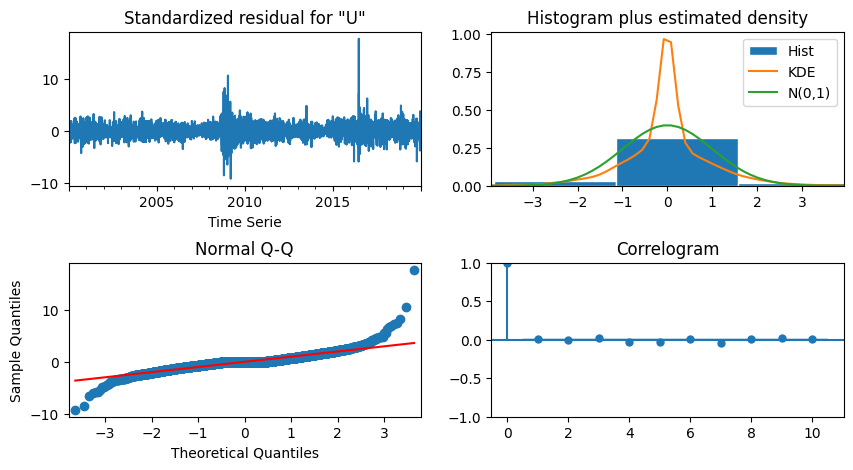

In [ ]:
result.plot_diagnostics(figsize = (10,5))
plt.subplots_adjust(hspace = 0.5)
plt.show()

In [ ]:
result = ARIMA(df_week['EURO AREA - EURO/US$'], order = model.order, seasonal_order = model.seasonal_order).fit()

# For in-sample predictions, we predict over the entire series that was used for fitting
predictions = result.predict(start=0, end=len(df_week)-1, typ = 'levels')

print('Evaluation Result for original levels data : ','\n')
print('R2 Score : {0:.2f} %'.format(100*r2_score(df_week['EURO AREA - EURO/US$'], predictions_levels)),'\n')
print('Mean Squared Error : ',mean_squared_error(df_week['EURO AREA - EURO/US$'], predictions_levels),'\n')
print('Mean Absolute Error : ',mean_absolute_error(df_week['EURO AREA - EURO/US$'], predictions_levels),'\n')
print('Root Mean Squared Error : ',sqrt(mean_squared_error(df_week['EURO AREA - EURO/US$'], predictions_levels)),'\n')
print('Mean Absolute Percentage Error : {0:.2f} %'.format(100*mean_absolute_percentage_error(df_week['EURO AREA - EURO/US$'], predictions)))

Evaluation Result for original levels data :  

R2 Score : 93.86 % 

Mean Squared Error :  0.0009821130624208963 

Mean Absolute Error :  0.00761465683552277 

Root Mean Squared Error :  0.03133868316347859 

Mean Absolute Percentage Error : 0.88 %


##Model testing

In [ ]:
size = int(len(df_week)*0.80)
train , test = df_week[0:size]['EURO AREA - EURO/US$'] , df[size:(len(df_week))]['EURO AREA - EURO/US$']
print('Counts of Train Data : ',train.shape[0])
print('Counts of Test Data : ',test.shape[0])

Counts of Train Data :  835
Counts of Test Data :  209


In [ ]:
train_df = [x for x in train]
prediction = []
print('Printing Predictied vs Expected Values....')
print('\n')
for t in range(len(test)):
    model = ARIMA(train_df , order = (0,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    pred_out = output[0]
    prediction.append(float(pred_out))
    test_in = test[t]
    train_df.append(test_in)
    print('Predicted = %f , Actual = %f' % (pred_out , test_in))

Printing Predictied vs Expected Values....


Predicted = 0.918086 , Actual = 1.125500
Predicted = 1.125500 , Actual = 1.123800
Predicted = 1.123800 , Actual = 1.124500
Predicted = 1.124500 , Actual = 1.124500
Predicted = 1.124500 , Actual = 1.124500
Predicted = 1.124500 , Actual = 1.126500
Predicted = 1.126500 , Actual = 1.124000
Predicted = 1.124000 , Actual = 1.121700
Predicted = 1.121700 , Actual = 1.113800
Predicted = 1.113800 , Actual = 1.113600
Predicted = 1.113600 , Actual = 1.113600
Predicted = 1.113600 , Actual = 1.113600
Predicted = 1.113600 , Actual = 1.107700
Predicted = 1.107700 , Actual = 1.110900
Predicted = 1.110900 , Actual = 1.103500
Predicted = 1.103500 , Actual = 1.107200
Predicted = 1.107200 , Actual = 1.094900
Predicted = 1.094900 , Actual = 1.094900
Predicted = 1.094900 , Actual = 1.094900
Predicted = 1.094900 , Actual = 1.091000
Predicted = 1.091000 , Actual = 1.093100
Predicted = 1.093100 , Actual = 1.106200
Predicted = 1.106200 , Actual = 1.100400
Predicted = 

In [ ]:
print('Evaluation Result for Test data : ','\n')
print('R2 Score for Test data : {0:.2f} %'.format(100*r2_score(test,prediction)),'\n')
print('Mean Squared Error : ',mean_squared_error(test,prediction),'\n')
print('Mean Absolute Error : ',mean_absolute_error(test,prediction),'\n')
print('Root Mean Squared Error : ',sqrt(mean_squared_error(test,prediction)),'\n')
print('Mean Absolute Percentage Error : {0:.2f} %'.format(100*mean_absolute_percentage_error(test,prediction)))

Evaluation Result for Test data :  

R2 Score for Test data : 82.50 % 

Mean Squared Error :  0.00023435792305438906 

Mean Absolute Error :  0.0044201640464798415 

Root Mean Squared Error :  0.015308753151527039 

Mean Absolute Percentage Error : 0.42 %


In [ ]:
predcitions_df = pd.Series(prediction, index = test.index)

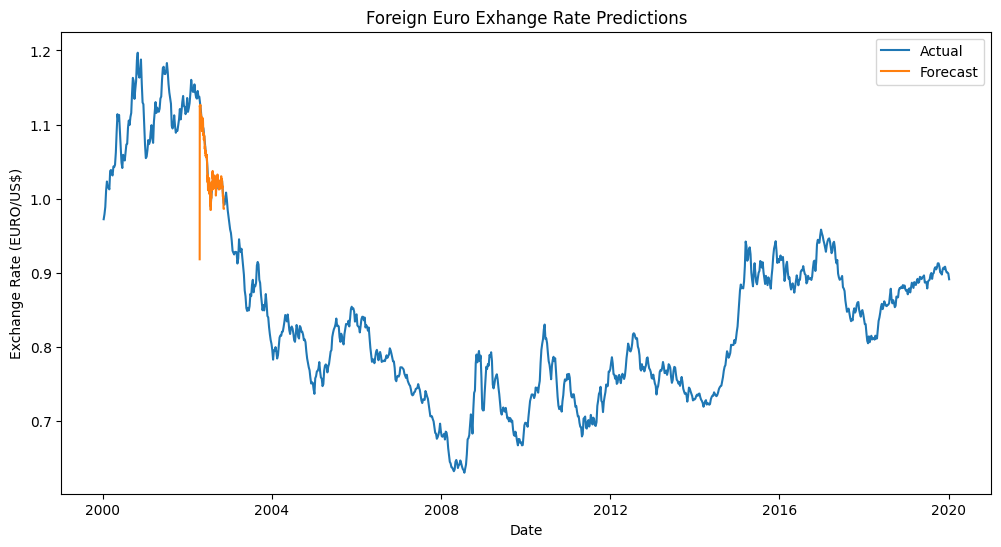

In [ ]:
plt.figure(figsize = (12,6))
plt.title('Foreign Euro Exhange Rate Predictions')
plt.plot(df_week['EURO AREA - EURO/US$'], label = 'Actual')
plt.plot(predcitions_df , label = 'Forecast')
plt.legend(loc = 'upper right')
plt.ylabel('Exchange Rate (EURO/US$)')
plt.xlabel('Date')
plt.show()